# Missing value imputation for animal husbandry data using KNN imputer

## Importing all the necessary libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
# Set the environment variable to avoid the memory leak warning
import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings('ignore')

## Load the data

In [5]:
df = pd.read_excel('data-matrix.xlsx', sheet_name = 'data_ori_knn')

In [6]:
df

,husbandry,sow,insem.group,cort.sal.105dpc,cort.sal.8dpp,bioact.ser.30dpc,bioact.ser.105dpc,bioact.ser.8dpp,igf2.ser.105dpc,igf2.ser.8dpp,igf1.ser.105dpc,igf1.ser.8dpp,igfbp2.ser.105dpc,igfbp2.ser.8dpp,igfbp3.ser.105dpc,igfbp3.ser.8dpp,stc1.105dpc,stc1.8dpp
0,conventional,6733,226,15.692458,8.142019,394.110959,406.753664,595.497520,54.14140,90.54503,54.38060,198.814905,698.722890,510.604700,994.150665,4922.471195,161.255614,95.634144
1,conventional,6733,247,8.219267,0.871795,273.960527,330.081876,394.783879,47.86450,85.02695,215.46452,291.334500,497.077300,403.477400,386.486150,309.904200,2429.711326,1282.963044
2,conventional,6733,316,NaN,NaN,126.242083,222.199369,201.608261,NaN,NaN,NaN,NaN,674.911207,494.125767,1627.241972,1530.276230,NaN,NaN
3,conventional,6734,226,25.955737,3.728019,437.318347,400.245899,305.424538,114.68749,122.19062,322.41636,336.480550,487.929650,498.147500,419.664050,354.951850,4672.325007,2255.126746
4,conventional,6734,247,6.733704,5.227539,521.884666,548.915866,484.520992,51.44784,105.35780,362.08984,222.512800,858.146800,795.680800,633.777050,356.590100,8402.516856,8630.403633
5,conventional,6734,316,NaN,NaN,42.506589,55.419458,26.482360,NaN,NaN,NaN,NaN,373.973320,524.447220,1874.485920,4932.430170,NaN,NaN
6,conventional,6791,247,10.584996,4.767671,385.138044,342.222969,218.510180,59.54401,99.78639,50.63900,90.572000,665.296710,477.079760,780.466240,1430.327375,78.413293,49.892760
7,conventional,6791,316,NaN,NaN,143.484369,180.133721,147.854932,NaN,NaN,NaN,NaN,538.769273,946.694128,758.345812,1738.646203,NaN,NaN
8,conventional,6791,337,NaN,NaN,97.526396,121.450272,85.891698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,conventional,6794,247,16.983811,1.619386,411.682647,531.097570,492.558532,62.25304,110.94903,47.60020,185.764220,606.959580,461.374340,603.124490,1552.004360,37.399958,35.318449


In [7]:
df.shape

(40, 18)

In [8]:
df.columns

Index(['husbandry', 'sow', 'insem.group', 'cort.sal.105dpc', 'cort.sal.8dpp',
       'bioact.ser.30dpc', 'bioact.ser.105dpc', 'bioact.ser.8dpp',
       'igf2.ser.105dpc', 'igf2.ser.8dpp', 'igf1.ser.105dpc', 'igf1.ser.8dpp',
       'igfbp2.ser.105dpc', 'igfbp2.ser.8dpp', 'igfbp3.ser.105dpc',
       'igfbp3.ser.8dpp', 'stc1.105dpc', 'stc1.8dpp'],
      dtype='object')

## Check how many missing values are there in the data

In [10]:
df.isna().sum()

husbandry             0
sow                   0
insem.group           0
cort.sal.105dpc      20
cort.sal.8dpp        20
bioact.ser.30dpc      1
bioact.ser.105dpc     0
bioact.ser.8dpp       0
igf2.ser.105dpc      20
igf2.ser.8dpp        20
igf1.ser.105dpc      18
igf1.ser.8dpp        18
igfbp2.ser.105dpc     4
igfbp2.ser.8dpp       4
igfbp3.ser.105dpc     4
igfbp3.ser.8dpp       4
stc1.105dpc          20
stc1.8dpp            20
dtype: int64

In [11]:
df.isna().sum().sum()

173

In [12]:
 df.replace('', np.nan, inplace=True)

In [13]:
df['husbandry'].value_counts()

husbandry
conventional    20
ecological      20
Name: count, dtype: int64

In [14]:
mapping = {'conventional': 1, 'ecological': 0}
df = df.replace({'husbandry': mapping})

In [15]:
df.isna().sum().sum()

173

### Visualizing the missing value pattern in the data

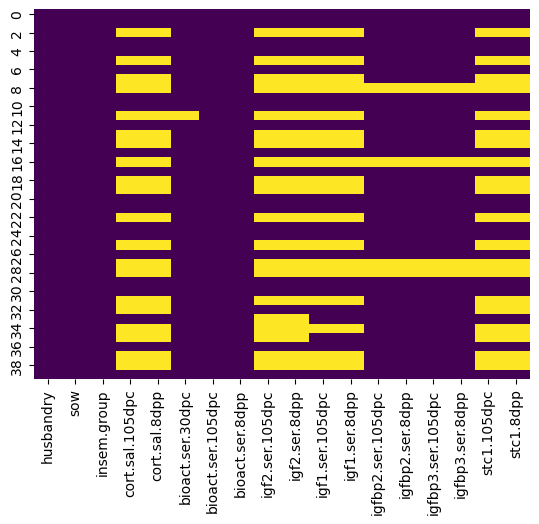

In [17]:
# Summary statistics
missing_data_summary = df.isnull().sum()

# Heatmap of missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

## Impute missing values seperately for the two husbandry systems using KNN imputer
- Seperate the data into two data frames based on husbandry system
- Appy the function to impute the missing values

In [19]:
#Function to impute missing values
def impute_missing_values_knn(data_missing, n_neighbors = 5, weights = 'uniform'):
    """
    Imputes missing values in a dataset using K-Nearest Neighbors (KNN) imputation.
    
    Parameters:
    data_missing (numpy.ndarray): 2D array with missing values represented by np.nan.
    n_neighbors (int): Number of neighbors to use for KNN imputation.
    
    Returns:
    numpy.ndarray: Data with imputed missing values.
    """
    imputer = KNNImputer(n_neighbors = n_neighbors)
    data_imputed = imputer.fit_transform(data_missing)
    
    return data_imputed


In [20]:
conventional_df = df[df['husbandry']==1]
conventional_df.shape

(20, 18)

In [21]:
conventional_df.isna().sum().sum()

89

In [22]:
ecological_df = df[df['husbandry']==0]
ecological_df.shape

(20, 18)

In [23]:
ecological_df.isna().sum().sum()

84

In [24]:
imputed_conventional_df = impute_missing_values_knn(conventional_df)
imputed_conventional_df = pd.DataFrame(imputed_conventional_df, columns = df.columns)

In [25]:
imputed_ecological_df = impute_missing_values_knn(ecological_df)
imputed_ecological_df = pd.DataFrame(imputed_ecological_df, columns = df.columns)

In [26]:
imputed_df = pd.concat([imputed_conventional_df,imputed_ecological_df],axis=0)
imputed_df.shape

(40, 18)

In [27]:
imputed_df = imputed_df.reset_index(drop = True)

### Saving the imputed data in the excel format

In [29]:
imputed_df.to_excel('data_imputed.xlsx', index=False)